In [62]:
## Load muckrakers

import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os




In [63]:
## Read in the information

def get_donors(file_name):
    df = pd.read_csv(file_name, delimiter=',', header = 0)
    return df



In [64]:
df = get_donors('Donors_Data.csv')
## See if it worked

print(df.head)

<bound method NDFrame.head of       Row Id  Row Id.  zipconvert_2  zipconvert_3  zipconvert_4  zipconvert_5  \
0          1       17             0             1             0             0   
1          2       25             1             0             0             0   
2          3       29             0             0             0             1   
3          4       38             0             0             0             1   
4          5       40             0             1             0             0   
...      ...      ...           ...           ...           ...           ...   
3115    3116    23256             0             0             0             1   
3116    3117    23258             0             1             0             0   
3117    3118    23261             0             0             0             1   
3118    3119    23265             0             0             0             1   
3119    3120    23293             0             0             1             0  

In [65]:
def clean_col_names(df):
    df=df.rename(columns=lambda col: col.replace(' dummy',''))
    return df

df = clean_col_names(df)

print(df.head)

<bound method NDFrame.head of       Row Id  Row Id.  zipconvert_2  zipconvert_3  zipconvert_4  zipconvert_5  \
0          1       17             0             1             0             0   
1          2       25             1             0             0             0   
2          3       29             0             0             0             1   
3          4       38             0             0             0             1   
4          5       40             0             1             0             0   
...      ...      ...           ...           ...           ...           ...   
3115    3116    23256             0             0             0             1   
3116    3117    23258             0             1             0             0   
3117    3118    23261             0             0             0             1   
3118    3119    23265             0             0             0             1   
3119    3120    23293             0             0             1             0  

In [66]:
def transform_data(df):
    # append a new column to the end of the data frame that is based on the highest index value
    # in the zip_convert columns, which are binary values set to 0 or 1
    df['region'] = df.loc[:, 'zipconvert_2':'zipconvert_5'].idxmax(axis=1)

    # replace the zipconvert_ value with blanks using a regular expression
    df = df.replace({'region': 'zipconvert_'}, {'region':''}, regex=True)

    # drop extraneous columns
    df.drop(['Row Id.', 'zipconvert_2', 'zipconvert_3', 'zipconvert_4', 'zipconvert_5'],  axis=1, inplace=True)
    return df

df = transform_data(df)

print(df.head)

<bound method NDFrame.head of       Row Id  homeowner  NUMCHLD  INCOME  gender  WEALTH    HV  Icmed  Icavg  \
0          1          1        1       5       1       9  1399    637    703   
1          2          1        1       1       0       7   698    422    463   
2          3          0        2       5       1       8   828    358    376   
3          4          1        1       3       0       4  1471    484    546   
4          5          1        1       4       0       8   547    386    432   
...      ...        ...      ...     ...     ...     ...   ...    ...    ...   
3115    3116          1        1       4       0       8   697    337    372   
3116    3117          0        1       2       0       8   590    319    400   
3117    3118          1        1       3       0       7  3129    547    580   
3118    3119          1        1       7       1       8  1345    514    525   
3119    3120          1        1       5       1       4   882    315    374   

      IC1

In [67]:
## Check for missing information 
def check_null(df):
    missing_values= df.isnull().sum()
    print( missing_values)
    
check_null(my_df)

homeowner      0
NUMCHLD        0
INCOME         0
gender         0
WEALTH         0
HV             0
Icmed          0
Icavg          0
IC15           0
NUMPROM        0
RAMNTALL       0
MAXRAMNT       0
LASTGIFT       0
totalmonths    0
TIMELAG        0
AVGGIFT        0
TARGET_B       0
TARGET_D       0
region         0
dtype: int64


In [68]:
## After the define, moves all reading in and cleaning into one window along with the null check
## Describe brings summary stats for the df

file_name = "Donors_Data.csv"
donor_data = get_donors(file_name)
donor_data = clean_col_names(donor_data)
donor_data = transform_data(donor_data)
check_null(donor_data)

donor_data.describe()

Row Id         0
homeowner      0
NUMCHLD        0
INCOME         0
gender         0
WEALTH         0
HV             0
Icmed          0
Icavg          0
IC15           0
NUMPROM        0
RAMNTALL       0
MAXRAMNT       0
LASTGIFT       0
totalmonths    0
TIMELAG        0
AVGGIFT        0
TARGET_B       0
TARGET_D       0
region         0
dtype: int64


,Row Id,homeowner,NUMCHLD,INCOME,gender,WEALTH,HV,Icmed,Icavg,IC15,NUMPROM,RAMNTALL,MAXRAMNT,LASTGIFT,totalmonths,TIMELAG,AVGGIFT,TARGET_B,TARGET_D
count,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.00000,3120.000000
mean,1560.500000,0.770192,1.069231,3.893910,0.609295,6.402244,1141.361859,388.217308,432.088141,14.702885,49.089423,110.399875,16.651397,13.522917,31.136859,6.861859,10.690713,0.50000,6.499612
std,900.810746,0.420777,0.347688,1.636186,0.487987,2.539978,946.642162,172.815950,168.195104,12.079882,22.717130,147.299933,22.223521,10.581439,4.132952,5.561209,7.443980,0.50008,10.597849
min,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,15.000000,5.000000,0.000000,17.000000,0.000000,2.138889,0.00000,0.000000
25%,780.750000,1.000000,1.000000,3.000000,0.000000,5.000000,556.000000,278.000000,318.000000,5.000000,29.000000,45.000000,10.000000,7.000000,29.000000,3.000000,6.356092,0.00000,0.000000
50%,1560.500000,1.000000,1.000000,4.000000,1.000000,8.000000,822.000000,356.000000,396.000000,12.000000,48.000000,81.000000,15.000000,10.000000,31.000000,5.000000,9.000000,0.50000,0.500000
75%,2340.250000,1.000000,1.000000,5.000000,1.000000,8.000000,1338.750000,465.000000,516.000000,21.000000,65.000000,134.625000,20.000000,16.000000,34.000000,9.000000,12.811652,1.00000,10.000000
max,3120.000000,1.000000,5.000000,7.000000,1.000000,9.000000,5945.000000,1500.000000,1331.000000,90.000000,157.000000,5674.900000,1000.000000,219.000000,37.000000,77.000000,122.166667,1.00000,200.000000


In [69]:
## Print a list of current column names
def print_col_names(df):
    print(df.columns.tolist())
    
print_col_names(donor_data)

['Row Id', 'homeowner', 'NUMCHLD', 'INCOME', 'gender', 'WEALTH', 'HV', 'Icmed', 'Icavg', 'IC15', 'NUMPROM', 'RAMNTALL', 'MAXRAMNT', 'LASTGIFT', 'totalmonths', 'TIMELAG', 'AVGGIFT', 'TARGET_B', 'TARGET_D', 'region']


In [70]:
# Subset specific columns and rename them

def create_subset(df):
    donations_df = df[['Row Id', 'LASTGIFT', 'AVGGIFT']].rename(columns={'Row Id': 'donor', 'LASTGIFT': 'last_donation','AVGGIFT' : 'avg_donation' })
    donations_df = pd.DataFrame(donations_df, columns=['donor','last_donation','avg_donation'])

    #This column will tell me the difference between the last donation and the average.

    donations_df['d_change'] = donations_df['last_donation']-donations_df['avg_donation']
    return donations_df


In [71]:
# Display the new DataFrame

donations_df = create_subset(donor_data)

donations_df.describe()

,donor,last_donation,avg_donation,d_change
count,3120.000000,3120.000000,3120.000000,3120.000000
mean,1560.500000,13.522917,10.690713,2.832203
std,900.810746,10.581439,7.443980,5.585070
min,1.000000,0.000000,2.138889,-23.529412
25%,780.750000,7.000000,6.356092,0.000000
50%,1560.500000,10.000000,9.000000,1.842432
75%,2340.250000,16.000000,12.811652,4.349530
max,3120.000000,219.000000,122.166667,96.833333


In [72]:
def plot_donation_shift(df):
    #Set index
    df = df.set_index('donor')
    df['d_change'].hist(bins = 75, color= '#92cf51', edgecolor = 'black')
    plt.xlabel('Change in Donation Amount')
    plt.ylabel('Donor Count')
    plt.title('Shift in Donation Amount from Average')
    
    # Plot line at 0 mark
    plt.axvline(x=0, color='red', linestyle=':', label='0')
    
    #Set bounds for HDI
    lower_bound = np.percentile(df, 2.5)
    upper_bound = np.percentile(df, 97.5)
    
    # Draw vertical lines at the bounds
    plt.axvline(lower_bound, color='#2c8af5', linestyle='dashed', linewidth=2, label='LB(2.5%)')
    plt.axvline(upper_bound, color='#2c8af5', linestyle='dashed', linewidth=2, label='UB(97.5%)')

    


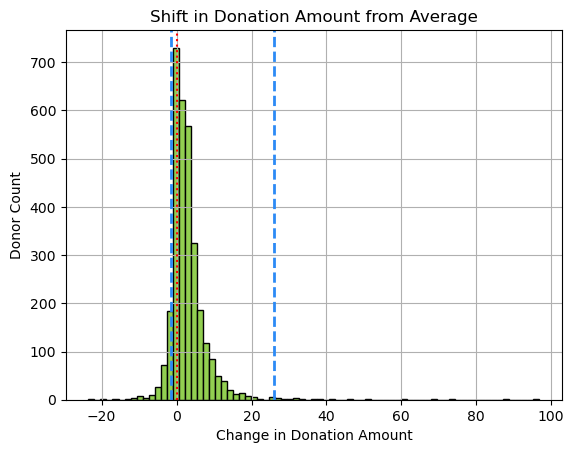

In [73]:
plot_donation_shift(donations_df)

In [74]:
## Run a report on donor behavior over time, this is with the original DF
def gen_donor_report(df):
    #Grab the columns I want and rename them
    donor_report =  df[['Row Id','WEALTH', 'LASTGIFT', 'AVGGIFT','TIMELAG']].rename(columns={'Row Id': 'donor', 'WEALTH' : 'wealth_cat',
                                                                                            'LASTGIFT': 'last_donation','AVGGIFT' : 'avg_donation','TIMELAG' : 'time_bw_donation' })
    #Create the new datafrome.
    donor_report = pd.DataFrame(donor_report, columns=['wealth_cat','last_donation','avg_donation','time_bw_donation'])
    #Include the aggregate function column
    donor_report['d_change'] = donor_report['last_donation']-donor_report['avg_donation']
    #Set the index to wealth category
    donor_report = donor_report.set_index('wealth_cat')
    #Create the pivot table that will serve as the report
    report = pd.pivot_table(donor_report, values='d_change', index=['wealth_cat'],
                       columns=['time_bw_donation'], aggfunc="mean")
    return report


In [75]:
report = gen_donor_report(donor_data)

In [76]:
## Write the csv
def export_report(report):
    file_path = input('Write file name including .csv extension')
    file_directory = os.getcwd()
    report.to_csv(file_path, index=False)
    print(f"CSV file '{file_path}' has been successfully written to the directory '{file_directory}'.")

In [77]:
export_report(report)

Write file name including .csv extension report1.csv


CSV file 'report1.csv' has been successfully written to the directory 'C:\Users\bendi\OneDrive\Documents\My.Master.Plan\IST 652 Scripting for Data\Assignments\data'.
